# 03 RFM 用户分层分析

**目标**：基于用户购买行为，将用户分为 8 个层级，制定差异化运营策略。

- **R (Recency)**：最近一次购买距今天数
- **F (Frequency)**：购买频次
- **M (Monetary)**：消费总金额

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, clean_data
from src.rfm import compute_rfm, score_rfm, label_users, rfm_summary, plot_rfm

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载数据
df, item_meta = load_data(use_simulated=True, n_users=5000)
df = clean_data(df)

生成模拟数据：5000 个用户...
共 138,206 条行为记录，6 个品类


In [3]:
# === 1. 计算 RFM ===
rfm = compute_rfm(df, item_meta)
print(f'有过购买行为的用户数：{len(rfm):,}')
rfm.head(10)

有过购买行为的用户数：2,161


,user_id,recency,frequency,monetary
0,4,17,1,838.36
1,6,3,6,6322.68
2,11,41,1,1530.21
3,12,56,1,839.61
4,19,24,2,1204.16
5,20,2,4,1170.65
6,23,33,1,739.12
7,25,9,1,758.96
8,30,2,1,481.12
9,31,51,1,1797.75


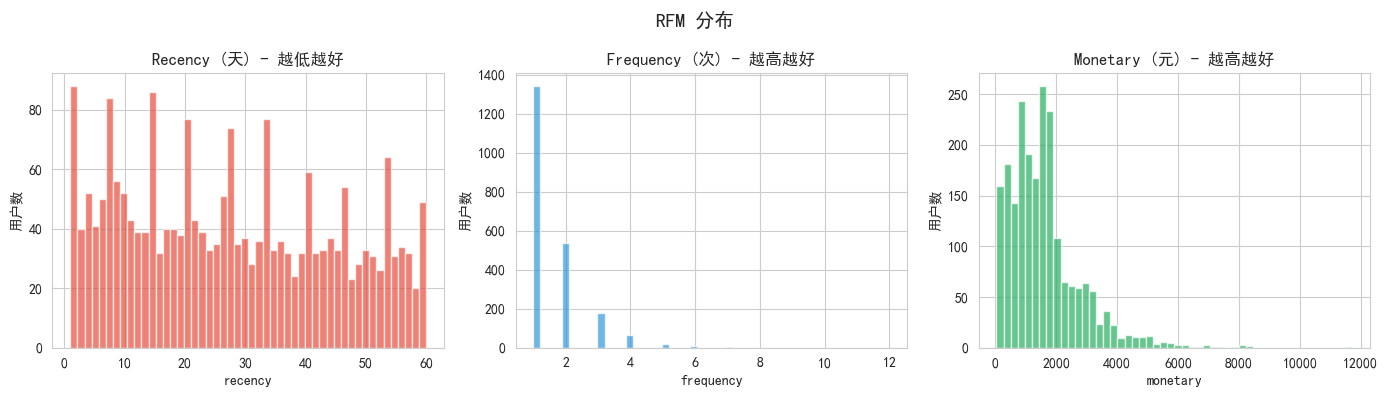

In [4]:
# RFM 分布概览
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title, color in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    ['Recency (天) - 越低越好', 'Frequency (次) - 越高越好', 'Monetary (元) - 越高越好'],
    ['#e74c3c', '#3498db', '#27ae60']
):
    ax.hist(rfm[col], bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('用户数')
plt.suptitle('RFM 分布', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# === 2. 打分并分层 ===
rfm_scored = score_rfm(rfm)
rfm_labeled = label_users(rfm_scored)

# 分层汇总
summary = rfm_summary(rfm_labeled)
summary

,用户数,占比,平均R,平均F,平均M
user_label,,,,,
一般挽留用户,743,34.4,2.3,1.5,1.5
重要价值用户,458,21.2,3.5,3.7,3.8
重要保持用户,284,13.1,1.6,3.5,3.6
重要挽留用户,194,9.0,1.4,1.5,3.0
重要发展用户,171,7.9,3.5,3.3,1.6
一般保持用户,167,7.7,1.5,3.1,1.5
一般价值用户,144,6.7,3.4,1.5,3.0


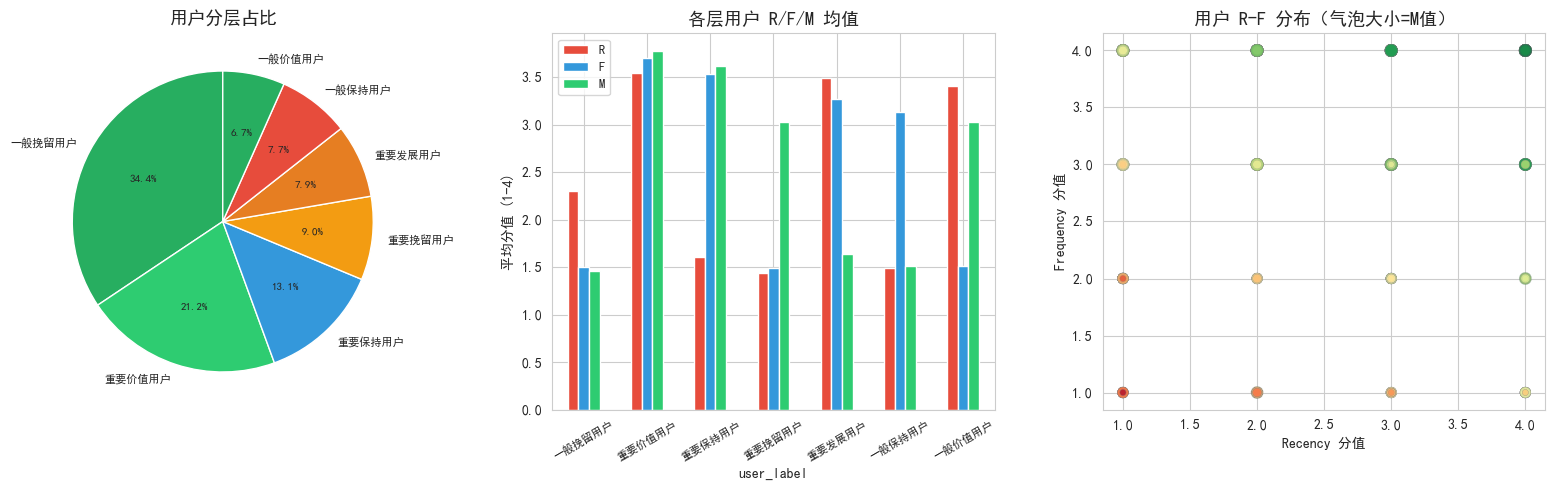

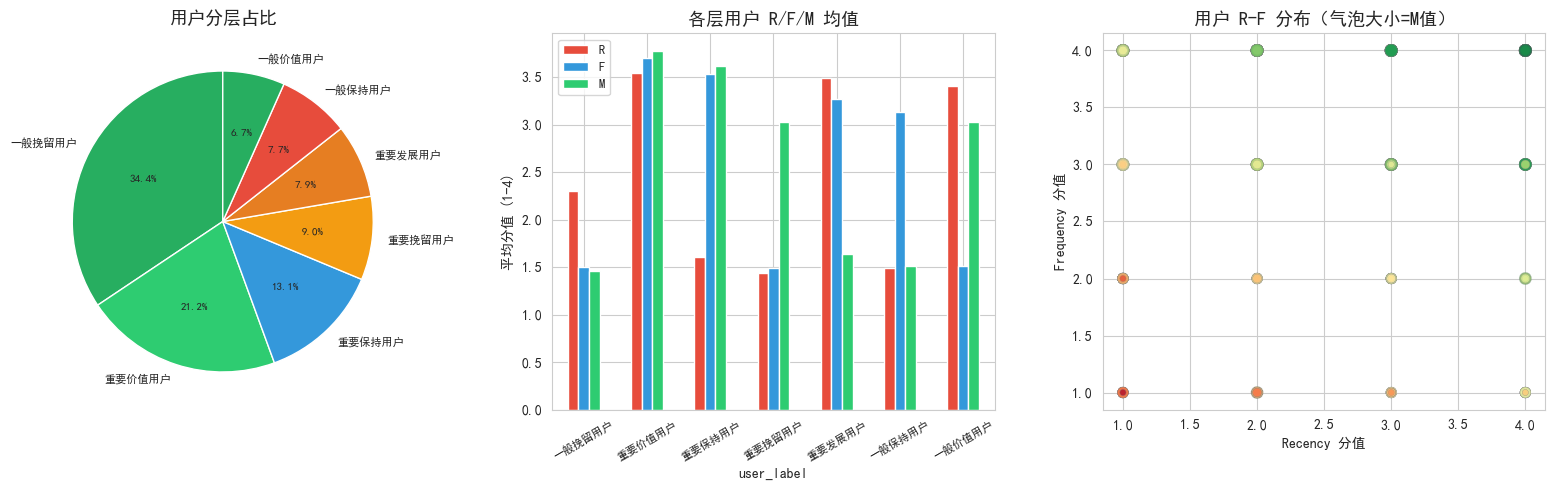

In [6]:
plot_rfm(rfm_labeled)

In [7]:
# === 3. 针对各层用户的运营建议 ===
strategies = {
    '重要价值用户': 'VIP 权益、专属客服、新品优先体验 —— 目标是留存和口碑传播',
    '重要发展用户': '满减券、限时折扣 —— 刺激消费金额提升',
    '重要保持用户': '签到提醒、Push 推送、会员日活动 —— 召回并提高活跃度',
    '重要挽留用户': '大额优惠券 + 定向召回邮件 —— 高价值但已流失，全力挽回',
    '一般价值用户': '关联推荐、凑单满减 —— 提高复购频次',
    '一般发展用户': '新人专享价、首单礼金 —— 降低决策门槛',
    '一般保持用户': '内容营销、签到积分 —— 低成本的召回方式',
    '一般挽留用户': '不再投入营销预算，自然观察',
}

for label, strategy in strategies.items():
    cnt = len(rfm_labeled[rfm_labeled['user_label'] == label])
    pct = cnt / len(rfm_labeled) * 100
    print(f'【{label}】{cnt}人 ({pct:.1f}%) → {strategy}')

【重要价值用户】458人 (21.2%) → VIP 权益、专属客服、新品优先体验 —— 目标是留存和口碑传播
【重要发展用户】171人 (7.9%) → 满减券、限时折扣 —— 刺激消费金额提升
【重要保持用户】284人 (13.1%) → 签到提醒、Push 推送、会员日活动 —— 召回并提高活跃度
【重要挽留用户】194人 (9.0%) → 大额优惠券 + 定向召回邮件 —— 高价值但已流失，全力挽回
【一般价值用户】144人 (6.7%) → 关联推荐、凑单满减 —— 提高复购频次
【一般发展用户】0人 (0.0%) → 新人专享价、首单礼金 —— 降低决策门槛
【一般保持用户】167人 (7.7%) → 内容营销、签到积分 —— 低成本的召回方式
【一般挽留用户】743人 (34.4%) → 不再投入营销预算，自然观察


---
### 本阶段结论
- 高价值用户（重要价值 + 重要保持）占比约 X%，贡献了约 Y% 的销售额
- 流失风险用户（重要挽留）占比约 Z%，需重点关注
- 核心建议：
  1. 对重要挽留用户发放大额优惠券
  2. 对重要发展用户推送满减活动
- 下一步：关联规则挖掘，指导交叉销售